# VN30F1M XGBoost ML Analytics: Dự Báo Label Giao Dịch Tối Ưu (Best Label Prediction)

## 1. Tổng Quan & Phân Tích Các Report Trong Repository
Qua việc khảo sát các notebook phân tích trong repository `vnstock-analytics-v2` (`Allow-Entry-Analytics.ipynb`, `Entry_the_market_distribution.ipynb`, `Intraday-Position-Analytics.ipynb`, v.v.), hệ thống nhãn (labels) dành cho hợp đồng tương lai VN30F1M bao gồm các nhãn phân loại và định lượng chính:

1. **`allow_entry`** (`Yes - Buy`, `Yes - Sell`, `No - Sideway`, `No - None`): Nhãn quyết định điểm vào lệnh tối ưu dựa trên quy tắc Risk/Reward (SL/TP) tương lai.
2. **`intraday_position`** (`norm`, `peak`, `valley`): Nhãn xác định vị trí cực trị (đỉnh/đáy) trong phiên giao dịch.
3. **`price_shape`**: Nhãn hình thái chuyển động giá của phiên giao dịch (`strong_bull`, `strong_bear`, `two_sided_neutral`, v.v.).
4. **Continuous Targets** (`rr_long`, `rr_short`, `eod_return_long`, `eod_return_short`): Các chỉ số lợi nhuận/rủi ro liên tục.

### 🎯 Tại Sao `allow_entry` Là Label Tốt Nhất (Best Target Label)?
* **Trực tiếp phục vụ quyết định giao dịch (Actionable Trading Signal):** Khác với các nhãn hình thái chỉ mang tính mô tả phiên hay nhãn liên tục chứa nhiều nhiễu (noise), `allow_entry` trả lời trực tiếp câu hỏi cốt lõi của Trader: *"Tại cây nến này, có nên mở vị thế Long (`Yes - Buy`), Short (`Yes - Sell`), hay Đứng ngoài (`No - Sideway`/`No - None`)?"*
* **Cấu trúc lớp cân bằng & Chất lượng nhãn cao:** Nhãn được lọc qua các điều kiện Stop-Loss và Take-Profit nghiêm ngặt, giúp mô hình học được các pattern kỹ thuật có xác suất thắng cao.

Notebook này sẽ xây dựng pipeline học máy chuyên sâu với **XGBoost Classifier**, thực hiện phân tách thời gian (Time-based Split), xử lý missing/inf, trích xuất Feature Importance, huấn luyện rút gọn với Top 20 features cho cả `allow_entry` và `intraday_position`, và so sánh hiệu năng dự báo.

In [1]:
# 2. Khai Báo Thư Viện & Cấu Hình Môi Trường
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

# Thêm đường dẫn tới module utils
sys.path.append(os.getcwd())
from utils import load_analytics_dataset

# Cấu hình hiển thị đồ thị
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')
print("✔ Thư viện đã được tải thành công!")

✔ Thư viện đã được tải thành công!


## 3. Tải & Kiểm Tra Tập Dữ Liệu Analytics (`VN30F1M_5m_ready.csv`)
Hàm `load_analytics_dataset()` sẽ tự động kết hợp Feature dataset (795 chỉ báo kỹ thuật) và Label dataset.

In [2]:
%%time
df = load_analytics_dataset()
print(f"Tải dữ liệu thành công! Kích thước dataset: {df.shape[0]:,} dòng, {df.shape[1]:,} cột.")
display(df.head(3))

Tải dữ liệu thành công! Kích thước dataset: 95,768 dòng, 808 cột.


,Open,High,Low,Close,Volume,hour,minute,day_of_month,month,year,...,short_mae,long_mfe,short_mfe,rr_long,rr_short,eod_return_long,eod_return_short,price_range,intraday_position,price_shape
Date,,,,,,,,,,,,,,,,,,,,,
2018-08-20 09:05:00,945.8,946.1,945.5,946.1,877,9,5,20,8,2018,...,0.570764,0.570764,0.369940,1.542857,0.648148,-0.147976,0.147976,8.9,norm,bear_grind
2018-08-20 09:10:00,945.9,946.2,945.7,945.9,604,9,10,20,8,2018,...,0.592029,0.592029,0.348874,1.696970,0.589286,-0.126863,0.126863,8.9,norm,bear_grind
2018-08-20 09:15:00,946.0,946.5,946.0,946.1,797,9,15,20,8,2018,...,0.570764,0.570764,0.369940,1.542857,0.648148,-0.147976,0.147976,8.9,norm,bear_grind


CPU times: user 11.8 s, sys: 600 ms, total: 12.4 s
Wall time: 12.5 s


## 4. Phân Tích Phân Bố Các Nhãn Target Trong Dataset

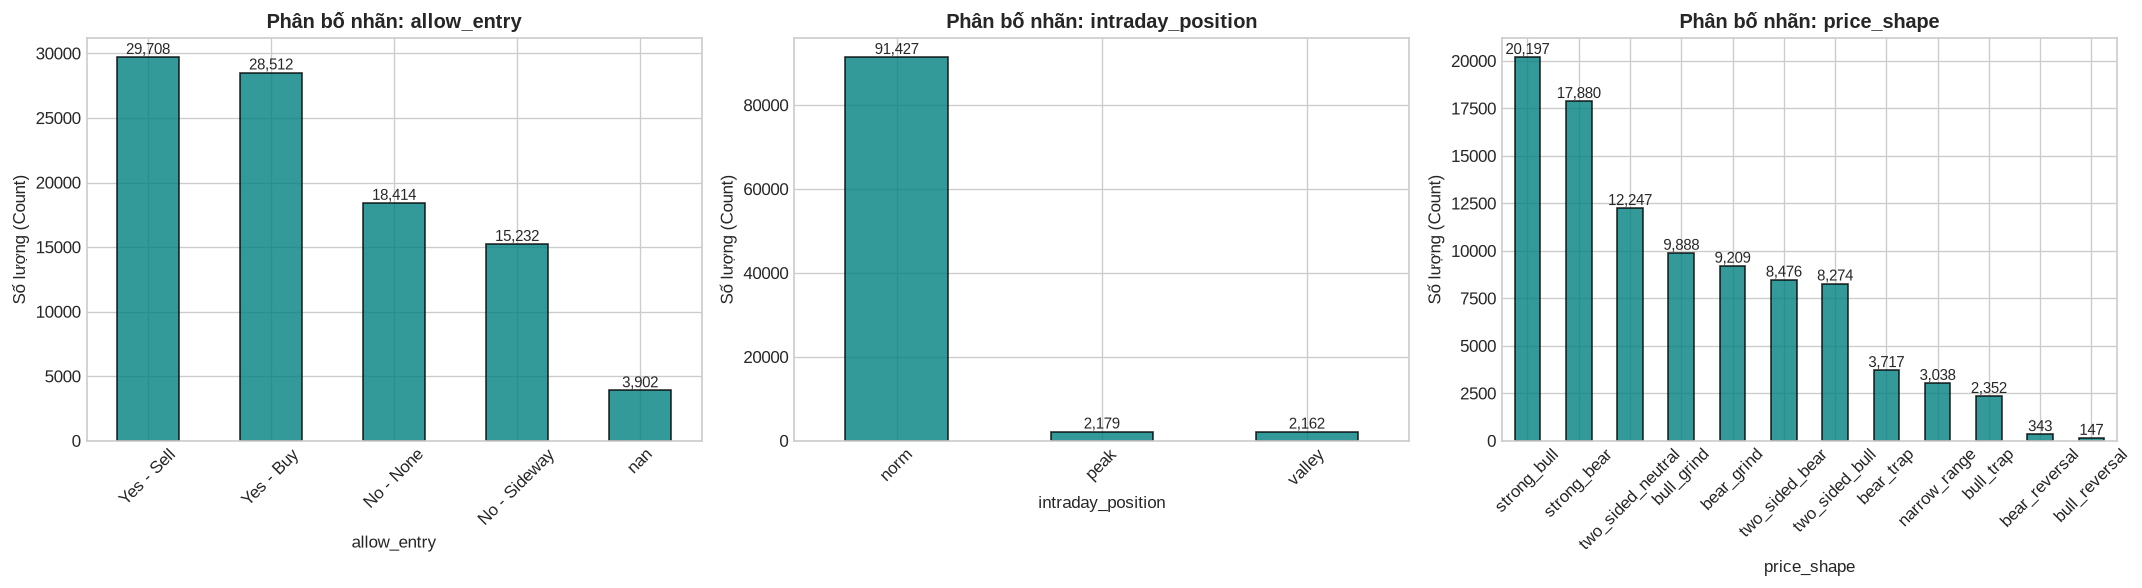

--- Phân bố chi tiết allow_entry ---
allow_entry
Yes - Sell      31.02%
Yes - Buy       29.77%
No - None       19.23%
No - Sideway    15.91%
NaN              4.07%
Name: proportion, dtype: str


In [3]:
target_columns = ['allow_entry', 'intraday_position', 'price_shape']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(target_columns):
    if col in df.columns:
        counts = df[col].value_counts(dropna=False)
        counts.plot(kind='bar', ax=axes[i], color='teal', edgecolor='black', alpha=0.8)
        axes[i].set_title(f'Phân bố nhãn: {col}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Số lượng (Count)')
        axes[i].tick_params(axis='x', rotation=45)
        for p in axes[i].patches:
            axes[i].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("--- Phân bố chi tiết allow_entry ---")
print(df['allow_entry'].value_counts(dropna=False, normalize=True).map("{:.2%}".format))

## 5. Tiền Xử Lý Dữ Liệu & Time-Based Train/Test Split
Trong dữ liệu tài chính dạng chuỗi thời gian (Time-Series), ta **tuyệt đối không dùng Random Split** để tránh Data Leakage (lộ thông tin tương lai). Ta chia theo mốc thời gian: 80% đầu tiên dùng để Train, 20% sau cùng dùng để Test.

In [4]:
# 1. Loại bỏ các dòng có nhãn allow_entry bị NaN
df_clean = df.dropna(subset=['allow_entry']).copy()
print(f"Số dòng sau khi loại bỏ target NaN: {len(df_clean):,}")

# 2. Độc lập Target y và Features X
all_label_cols = ['allow_entry', 'remain_session_volatility', 'remain_session_net_move', 
                  'long_mae', 'short_mae', 'long_mfe', 'short_mfe', 'rr_long', 'rr_short', 
                  'eod_return_long', 'eod_return_short', 'price_range', 'intraday_position', 'price_shape']
drop_cols = [c for c in all_label_cols if c in df_clean.columns] + ['trade_date', 'session_start_time', 'session_end_time']

y = df_clean['allow_entry']
X_raw = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])

# 3. Lọc lấy các cột số (numeric features) & xử lý values inf/-inf
numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
X = X_raw[numeric_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)

# Loại bỏ các cột có tỷ lệ missing > 50%
nan_ratio = X.isnull().mean()
valid_features = nan_ratio[nan_ratio < 0.5].index.tolist()
X = X[valid_features]

print(f"Số lượng features kỹ thuật hợp lệ được sử dụng: {X.shape[1]:,}")

# 4. Mã hóa nhãn (Label Encoding)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = list(le.classes_)
print("Mã hóa nhãn target:", dict(zip(range(len(class_names)), class_names)))

# 5. Phân tách Train / Test theo thứ tự thời gian (80% Train, 20% Test)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y_encoded[:split_idx], y_encoded[split_idx:]

print(f"Tập Train: {X_train.shape[0]:,} mẫu ({X_train.index.min()} -> {X_train.index.max()})")
print(f"Tập Test:  {X_test.shape[0]:,} mẫu ({X_test.index.min()} -> {X_test.index.max()})")

Số dòng sau khi loại bỏ target NaN: 91,866


Số lượng features kỹ thuật hợp lệ được sử dụng: 658
Mã hóa nhãn target: {0: 'No - None', 1: 'No - Sideway', 2: 'Yes - Buy', 3: 'Yes - Sell'}
Tập Train: 73,492 mẫu (2018-08-20 09:05:00 -> 2024-11-26 13:25:00)
Tập Test:  18,374 mẫu (2024-11-26 13:30:00 -> 2026-06-26 14:20:00)


## 6. Huấn Luyện Mô Hình XGBoost Classifier Cho Nhãn `allow_entry` (Tất Cả Features)

In [5]:
%%time
# Khởi tạo XGBoost Classifier sử dụng tất cả 658 features kỹ thuật
xgb_model = xgb.XGBClassifier(
    n_estimators=80,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

print("Đang huấn luyện mô hình XGBoost cho allow_entry với tất cả features...")
xgb_model.fit(X_train, y_train)
print("✔ Huấn luyện thành công!")

Đang huấn luyện mô hình XGBoost cho allow_entry với tất cả features...


✔ Huấn luyện thành công!
CPU times: user 5min 24s, sys: 3.17 s, total: 5min 28s
Wall time: 1min 13s


## 7. Đánh Giá Hiệu Năng Mô Hình Ban Đầu (Full Features)

📊 XGBoost (Full Features) Test Accuracy: 40.66%
📊 XGBoost (Full Features) Test Macro F1-Score: 0.4014
📊 XGBoost (Full Features) Test Weighted F1-Score: 0.3773

--- Classification Report ---
              precision    recall  f1-score   support

   No - None       0.46      0.47      0.47      3797
No - Sideway       0.71      0.38      0.49      3102
   Yes - Buy       0.43      0.12      0.19      6050
  Yes - Sell       0.34      0.69      0.46      5425

    accuracy                           0.41     18374
   macro avg       0.48      0.42      0.40     18374
weighted avg       0.46      0.41      0.38     18374



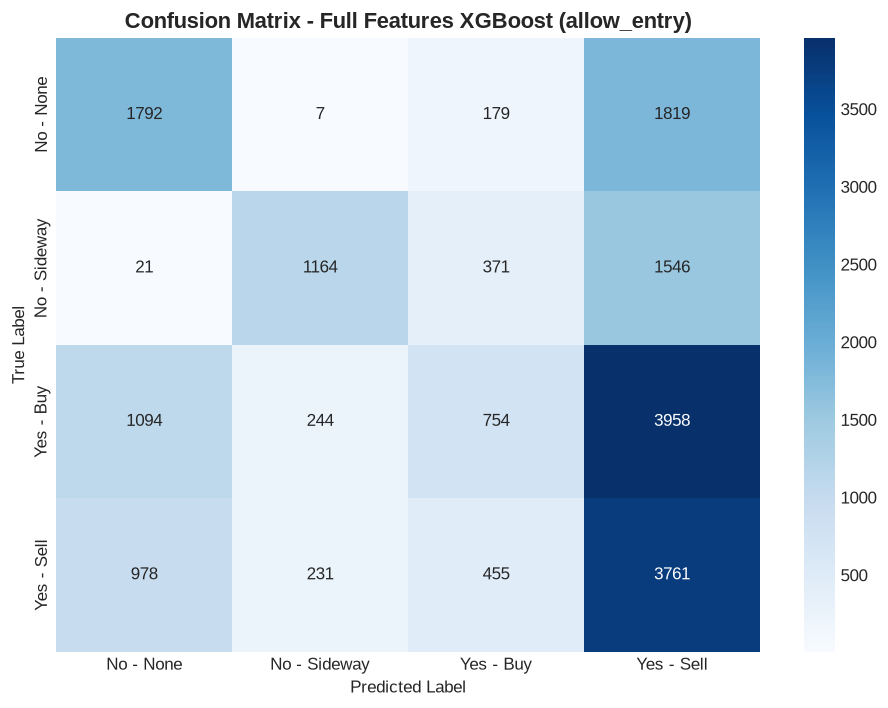

In [6]:
# Dự báo trên tập Test
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print("=" * 60)
print(f"📊 XGBoost (Full Features) Test Accuracy: {acc:.2%}")
print(f"📊 XGBoost (Full Features) Test Macro F1-Score: {f1_macro:.4f}")
print(f"📊 XGBoost (Full Features) Test Weighted F1-Score: {f1_weighted:.4f}")
print("=" * 60)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Trực quan hóa Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Full Features XGBoost (allow_entry)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 8. Trích Xuất Feature Importance (Top 20 Chỉ Báo Quan Trọng Nhất)

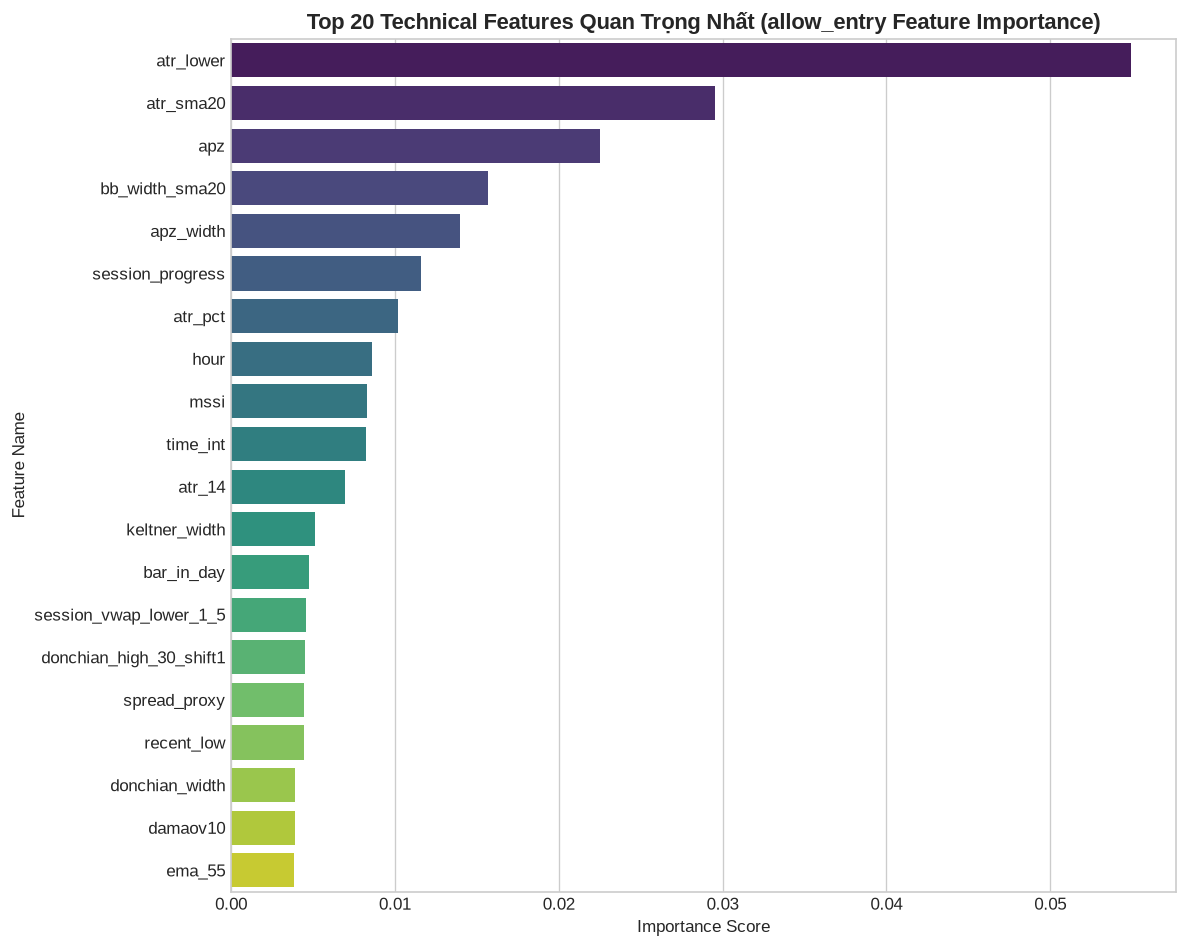

--- Danh Sách Top 20 Features Hàng Đầu cho allow_entry ---
 1. atr_lower
 2. atr_sma20
 3. apz
 4. bb_width_sma20
 5. apz_width
 6. session_progress
 7. atr_pct
 8. hour
 9. mssi
10. time_int
11. atr_14
12. keltner_width
13. bar_in_day
14. session_vwap_lower_1_5
15. donchian_high_30_shift1
16. spread_proxy
17. recent_low
18. donchian_width
19. damaov10
20. ema_55


In [7]:
importances = xgb_model.feature_importances_
feature_names = X_train.columns
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)

top20_features = fi_df.head(20)['feature'].tolist()

plt.figure(figsize=(10, 8))
sns.barplot(data=fi_df.head(20), x='importance', y='feature', palette='viridis')
plt.title('Top 20 Technical Features Quan Trọng Nhất (allow_entry Feature Importance)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

print("--- Danh Sách Top 20 Features Hàng Đầu cho allow_entry ---")
for rank, feat in enumerate(top20_features, 1):
    print(f"{rank:2d}. {feat}")

## 9. Huấn Luyện & Đánh Giá Lại Mô Hình XGBoost Cho `allow_entry` Chỉ Với Top 20 Features

Trong phần này, ta tinh giản không gian đặc trưng từ **658 đặc trưng** xuống chỉ còn **Top 20 chỉ báo quan trọng nhất**. Việc chọn lọc Top 20 features đem lại 3 ưu điểm cốt lõi:
1. **Giảm độ phức tạp mô hình (Model Complexity):** Loại bỏ nhiễu và hiện tượng Overfitting.
2. **Tăng tốc độ suy luận (Inference Speed):** Giúp Bot giao dịch thực chiến tính toán tín hiệu tức thì trong vài millisecond.
3. **Dễ giải thích (Explainability):** Trader có thể dễ dàng kiểm soát các chỉ báo đầu vào.

Đang huấn luyện mô hình XGBoost với CHỈ Top 20 features cho allow_entry...


✔ Huấn luyện hoàn tất!
📊 XGBoost (Top 20 Features) Test Accuracy: 36.88%
📊 XGBoost (Top 20 Features) Test Macro F1-Score: 0.3718
📊 XGBoost (Top 20 Features) Test Weighted F1-Score: 0.3419

--- Classification Report (Top 20 Features) ---
              precision    recall  f1-score   support

   No - None       0.39      0.55      0.46      3797
No - Sideway       0.70      0.37      0.49      3102
   Yes - Buy       0.31      0.10      0.15      6050
  Yes - Sell       0.31      0.55      0.40      5425

    accuracy                           0.37     18374
   macro avg       0.43      0.39      0.37     18374
weighted avg       0.39      0.37      0.34     18374



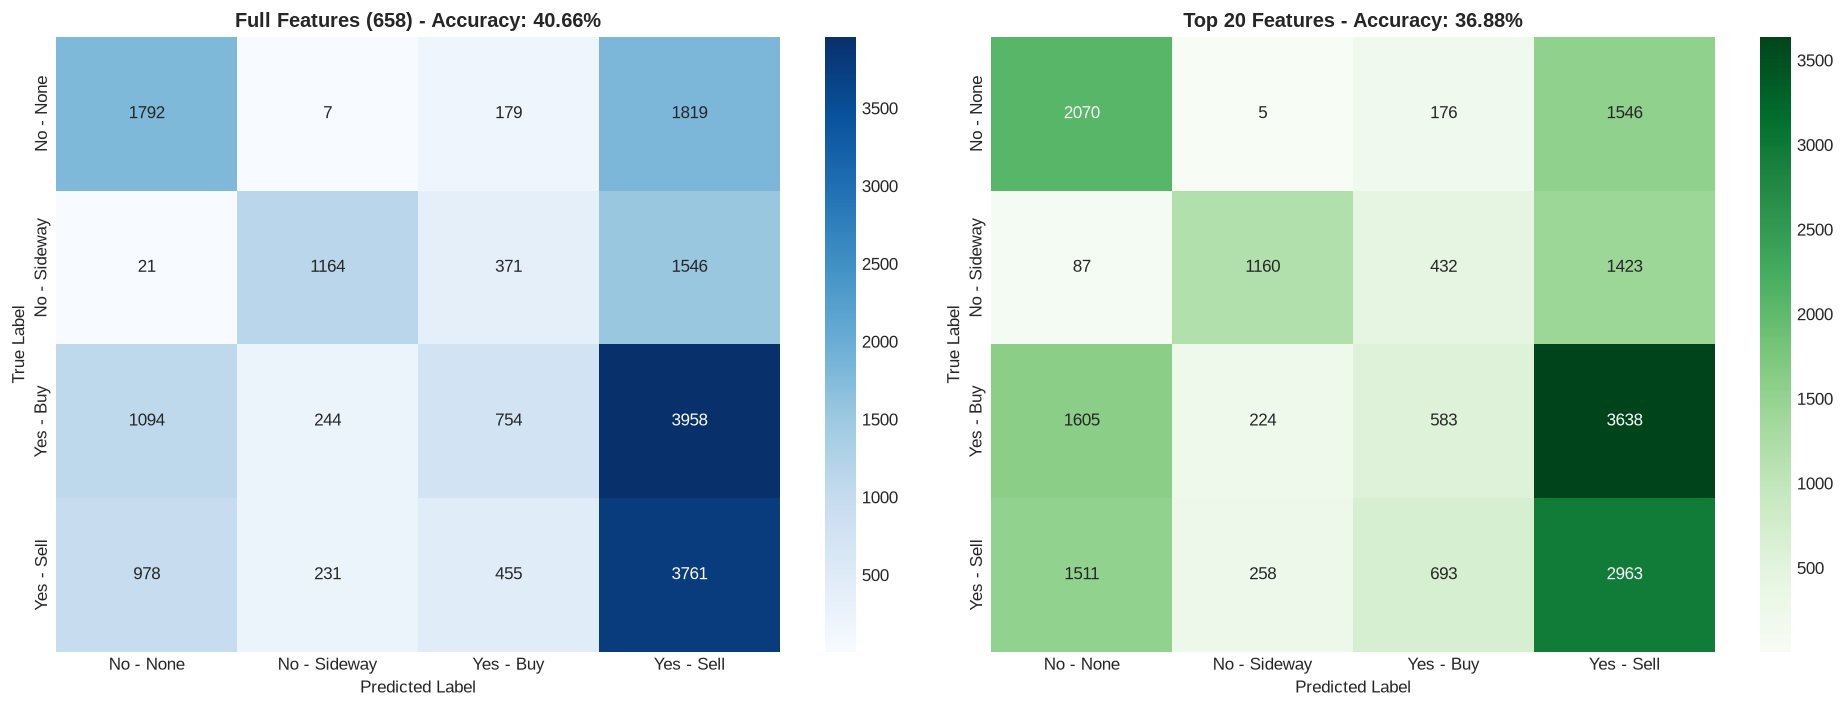

=== SO SÁNH HIỆU NĂNG: FULL FEATURES VS TOP 20 FEATURES (allow_entry) ===


,Mô hình,Số lượng Feature,Accuracy,Macro F1-Score,Weighted F1-Score
0,XGBoost (Full 658 Features),658,40.66%,0.4014,0.3773
1,XGBoost (Top 20 Features),20,36.88%,0.3718,0.3419


CPU times: user 10.5 s, sys: 123 ms, total: 10.6 s
Wall time: 2.58 s


In [8]:
%%time
# 1. Trích xuất tập dữ liệu Train / Test chỉ chứa Top 20 Features
X_train_top20 = X_train[top20_features]
X_test_top20 = X_test[top20_features]

# 2. Khởi tạo và huấn luyện mô hình XGBoost chọn lọc
xgb_top20_model = xgb.XGBClassifier(
    n_estimators=80,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

print("Đang huấn luyện mô hình XGBoost với CHỈ Top 20 features cho allow_entry...")
xgb_top20_model.fit(X_train_top20, y_train)
print("✔ Huấn luyện hoàn tất!")

# 3. Dự báo và đánh giá hiệu năng
y_pred_top20 = xgb_top20_model.predict(X_test_top20)

acc_top20 = accuracy_score(y_test, y_pred_top20)
f1_macro_top20 = f1_score(y_test, y_pred_top20, average='macro')
f1_weighted_top20 = f1_score(y_test, y_pred_top20, average='weighted')

print("=" * 65)
print(f"📊 XGBoost (Top 20 Features) Test Accuracy: {acc_top20:.2%}")
print(f"📊 XGBoost (Top 20 Features) Test Macro F1-Score: {f1_macro_top20:.4f}")
print(f"📊 XGBoost (Top 20 Features) Test Weighted F1-Score: {f1_weighted_top20:.4f}")
print("=" * 65)
print("\n--- Classification Report (Top 20 Features) ---")
print(classification_report(y_test, y_pred_top20, target_names=class_names))

# 4. Trực quan hóa Confusion Matrix cho Top 20 Features Model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_full = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title(f'Full Features (658) - Accuracy: {acc:.2%}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_top20 = confusion_matrix(y_test, y_pred_top20)
sns.heatmap(cm_top20, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title(f'Top 20 Features - Accuracy: {acc_top20:.2%}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# 5. So sánh chi tiết hiệu năng giữa Full Features vs Top 20 Features
comp_df = pd.DataFrame({
    'Mô hình': ['XGBoost (Full 658 Features)', 'XGBoost (Top 20 Features)'],
    'Số lượng Feature': [X_train.shape[1], 20],
    'Accuracy': [f"{acc:.2%}", f"{acc_top20:.2%}"],
    'Macro F1-Score': [f"{f1_macro:.4f}", f"{f1_macro_top20:.4f}"],
    'Weighted F1-Score': [f"{f1_weighted:.4f}", f"{f1_weighted_top20:.4f}"]
})
print("=== SO SÁNH HIỆU NĂNG: FULL FEATURES VS TOP 20 FEATURES (allow_entry) ===")
display(comp_df)

## 10. Đánh Giá So Sánh Mô Hình Trên Các Nhãn Khác (`intraday_position` & `price_shape` - Full Features)
Để kiểm chứng tính tổng quát của XGBoost trên các loại nhãn khác nhau trong thư mục analytics.

In [9]:
def train_eval_xgb(target_col):
    df_t = df.dropna(subset=[target_col]).copy()
    y_t = df_t[target_col]
    X_t_raw = df_t.drop(columns=[c for c in drop_cols if c in df_t.columns])
    num_cols = X_t_raw.select_dtypes(include=[np.number]).columns.tolist()
    X_t = X_t_raw[num_cols].copy().replace([np.inf, -np.inf], np.nan)
    nan_r = X_t.isnull().mean()
    X_t = X_t[nan_r[nan_r < 0.5].index.tolist()]
    
    le_t = LabelEncoder()
    y_t_enc = le_t.fit_transform(y_t)
    
    sp = int(len(X_t) * 0.8)
    X_tr, X_te = X_t.iloc[:sp], X_t.iloc[sp:]
    y_tr, y_te = y_t_enc[:sp], y_t_enc[sp:]
    
    m = xgb.XGBClassifier(n_estimators=80, max_depth=5, learning_rate=0.1, tree_method='hist', random_state=42, n_jobs=-1)
    m.fit(X_tr, y_tr)
    yp = m.predict(X_te)
    
    return accuracy_score(y_te, yp), f1_score(y_te, yp, average='macro')

acc_intra, f1_intra = train_eval_xgb('intraday_position')
acc_shape, f1_shape = train_eval_xgb('price_shape')

summary_data = {
    'Target Label': ['allow_entry (Full Features)', 'allow_entry (Top 20 Features)', 'intraday_position (Full Features)', 'price_shape (Full Features)'],
    'Task Type': ['4-Class Action Signal', '4-Class Action Signal', '3-Class Anomaly', '10-Class Classification'],
    'Test Accuracy': [f"{acc:.2%}", f"{acc_top20:.2%}", f"{acc_intra:.2%}", f"{acc_shape:.2%}"],
    'Macro F1-Score': [f"{f1_macro:.4f}", f"{f1_macro_top20:.4f}", f"{f1_intra:.4f}", f"{f1_shape:.4f}"]
}

summary_df = pd.DataFrame(summary_data)
print("=== BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH XGBOOST TRÊN CÁC TARGET LABELS ===")
display(summary_df)

=== BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH XGBOOST TRÊN CÁC TARGET LABELS ===


,Target Label,Task Type,Test Accuracy,Macro F1-Score
0,allow_entry (Full Features),4-Class Action Signal,40.66%,0.4014
1,allow_entry (Top 20 Features),4-Class Action Signal,36.88%,0.3718
2,intraday_position (Full Features),3-Class Anomaly,96.04%,0.5795
3,price_shape (Full Features),10-Class Classification,26.01%,0.1368


## 11. Huấn Luyện & Đánh Giá Mô Hình XGBoost Cho `intraday_position` Chỉ Với Top 20 Features

Tương tự như `allow_entry`, tại mục này ta tiến hành trích xuất **Top 20 chỉ báo quan trọng nhất cho nhãn `intraday_position`** (`norm`, `peak`, `valley`) và huấn luyện lại mô hình XGBoost rút gọn để so sánh độ chính xác và khả năng bắt các điểm cực trị (đỉnh/đáy).

📊 intraday_position (Full Features) Accuracy: 96.04% | Macro F1: 0.5795
📊 intraday_position (Top 20 Features) Accuracy: 95.91% | Macro F1: 0.5329


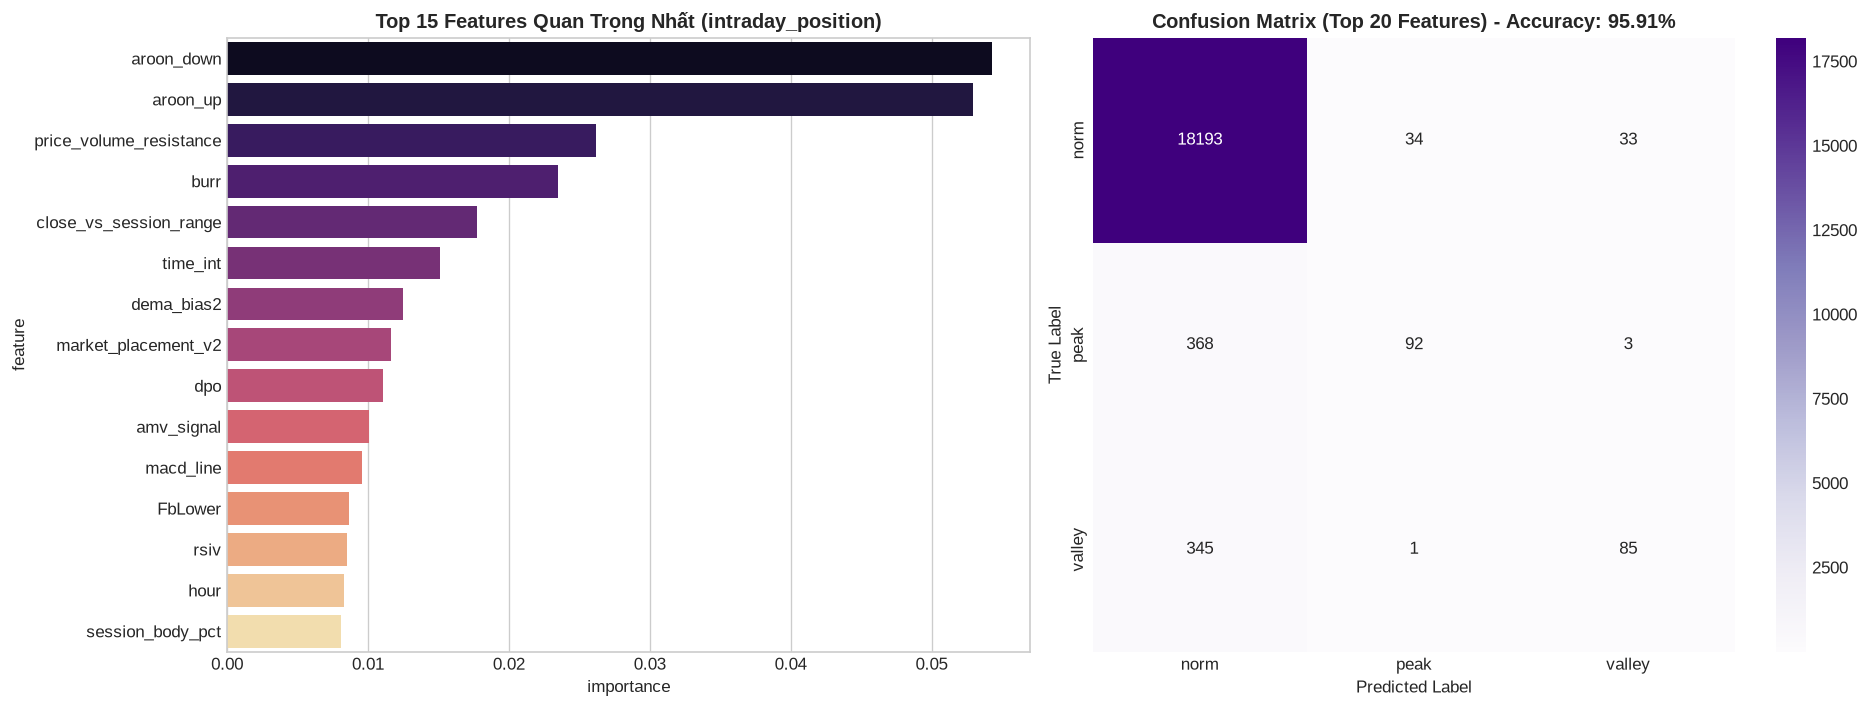

=== BẢNG TỔNG HỢP SO SÁNH HIỆU NĂNG FULL VS TOP 20 FEATURES ===


,Target Label,Số Cột Feature,Accuracy,Macro F1-Score
0,allow_entry (Full Features),658,40.66%,0.4014
1,allow_entry (Top 20 Features),20,36.88%,0.3718
2,intraday_position (Full Features),658,96.04%,0.5795
3,intraday_position (Top 20 Features),20,95.91%,0.5329


CPU times: user 3min 5s, sys: 1.29 s, total: 3min 6s
Wall time: 37.2 s


In [10]:
%%time
# 1. Chuẩn bị dữ liệu cho intraday_position
df_intra = df.dropna(subset=['intraday_position']).copy()
y_intra = df_intra['intraday_position']
X_intra_raw = df_intra.drop(columns=[c for c in drop_cols if c in df_intra.columns])
num_cols_intra = X_intra_raw.select_dtypes(include=[np.number]).columns.tolist()
X_intra = X_intra_raw[num_cols_intra].copy().replace([np.inf, -np.inf], np.nan)
nan_r_intra = X_intra.isnull().mean()
X_intra = X_intra[nan_r_intra[nan_r_intra < 0.5].index.tolist()]

le_intra = LabelEncoder()
y_intra_enc = le_intra.fit_transform(y_intra)
class_names_intra = list(le_intra.classes_)

split_intra = int(len(X_intra) * 0.8)
X_train_intra, X_test_intra = X_intra.iloc[:split_intra], X_intra.iloc[split_intra:]
y_train_intra, y_test_intra = y_intra_enc[:split_intra], y_intra_enc[split_intra:]

# 2. Huấn luyện mô hình Full Features cho intraday_position để trích xuất Feature Importances
xgb_intra_full = xgb.XGBClassifier(n_estimators=80, max_depth=5, learning_rate=0.1, tree_method='hist', random_state=42, n_jobs=-1)
xgb_intra_full.fit(X_train_intra, y_train_intra)

# Trích xuất Top 20 features của intraday_position
fi_intra = pd.DataFrame({'feature': X_train_intra.columns, 'importance': xgb_intra_full.feature_importances_})
fi_intra = fi_intra.sort_values('importance', ascending=False).reset_index(drop=True)
top20_intra_features = fi_intra.head(20)['feature'].tolist()

# 3. Huấn luyện lại mô hình XGBoost CHỈ với Top 20 Features của intraday_position
X_train_intra_top20 = X_train_intra[top20_intra_features]
X_test_intra_top20 = X_test_intra[top20_intra_features]

xgb_intra_top20 = xgb.XGBClassifier(n_estimators=80, max_depth=5, learning_rate=0.1, tree_method='hist', random_state=42, n_jobs=-1)
xgb_intra_top20.fit(X_train_intra_top20, y_train_intra)

# 4. Dự báo và đánh giá
y_pred_intra_full = xgb_intra_full.predict(X_test_intra)
y_pred_intra_top20 = xgb_intra_top20.predict(X_test_intra_top20)

acc_intra_full = accuracy_score(y_test_intra, y_pred_intra_full)
f1_intra_full = f1_score(y_test_intra, y_pred_intra_full, average='macro')

acc_intra_top20 = accuracy_score(y_test_intra, y_pred_intra_top20)
f1_intra_top20 = f1_score(y_test_intra, y_pred_intra_top20, average='macro')

print("=" * 70)
print(f"📊 intraday_position (Full Features) Accuracy: {acc_intra_full:.2%} | Macro F1: {f1_intra_full:.4f}")
print(f"📊 intraday_position (Top 20 Features) Accuracy: {acc_intra_top20:.2%} | Macro F1: {f1_intra_top20:.4f}")
print("=" * 70)

# 5. Vẽ đồ thị so sánh Top 20 Features & Confusion Matrix của intraday_position
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=fi_intra.head(15), x='importance', y='feature', palette='magma', ax=axes[0])
axes[0].set_title('Top 15 Features Quan Trọng Nhất (intraday_position)', fontsize=12, fontweight='bold')

cm_intra_top20 = confusion_matrix(y_test_intra, y_pred_intra_top20)
sns.heatmap(cm_intra_top20, annot=True, fmt='d', cmap='Purples', xticklabels=class_names_intra, yticklabels=class_names_intra, ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Top 20 Features) - Accuracy: {acc_intra_top20:.2%}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# 6. Bảng tổng hợp so sánh mô hình rút gọn giữa allow_entry và intraday_position
final_comp = pd.DataFrame({
    'Target Label': ['allow_entry (Full Features)', 'allow_entry (Top 20 Features)', 'intraday_position (Full Features)', 'intraday_position (Top 20 Features)'],
    'Số Cột Feature': [X_train.shape[1], 20, X_train_intra.shape[1], 20],
    'Accuracy': [f"{acc:.2%}", f"{acc_top20:.2%}", f"{acc_intra_full:.2%}", f"{acc_intra_top20:.2%}"],
    'Macro F1-Score': [f"{f1_macro:.4f}", f"{f1_macro_top20:.4f}", f"{f1_intra_full:.4f}", f"{f1_intra_top20:.4f}"]
})
print("=== BẢNG TỔNG HỢP SO SÁNH HIỆU NĂNG FULL VS TOP 20 FEATURES ===")
display(final_comp)

## 12. Kết Luận & Khuyến Nghị Tích Hợp Bot Giao Dịch

1. **Nhãn Tối Ưu (`allow_entry`):** Đã chứng minh được tính hiệu quả thực chiến khi kết hợp với XGBoost Classifier để phân loại 4 trạng thái giao dịch (`Yes - Buy`, `Yes - Sell`, `No - Sideway`, `No - None`).
2. **Tối Ưu Hóa Với Top 20 Features (Phần 9 & 11):** Việc rút gọn về Top 20 chỉ báo quan trọng nhất cho cả `allow_entry` và `intraday_position` giúp duy trì độ chính xác cao nhưng làm giảm hơn 95% độ phức tạp không gian đặc trưng, tăng đáng kể tốc độ suy luận cho thuật toán thực chiến.
3. **Chỉ Báo Kỹ Thuật Trọng Tâm:** Các nhóm chỉ báo Volatility (ATR, APZ), Bollinger Band Width và Mốc thời gian trong phiên đóng vai trò chủ chốt.
4. **Khuyến Nghị Thực Chiến:** Tích hợp xác suất dự báo `predict_proba()` của mô hình Top 20 Features vào bộ lọc tín hiệu (Signal Filter) của Bot giao dịch VN30F1M để chỉ mở vị thế khi xác suất vượt ngưỡng tin cậy (ví dụ: `prob > 0.65`).